# Газоконденсатное месторождение: комплексный анализ
## Курсовая работа

**Студент:** Каширин Егор Викторович

In [175]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.fluid import load_pvt_data
from src.reservoir import Reservoir
from src.pipe import Pipe

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

RHO_C = 0.6799
XA = 0.0651
XY = 0.9489
T_FIXED = 310.0

fluid, interp = load_pvt_data('interp_data.csv', RHO_C, XA, XY, T_FIXED)

## 1. PVT-МОДЕЛЬ ГАЗА

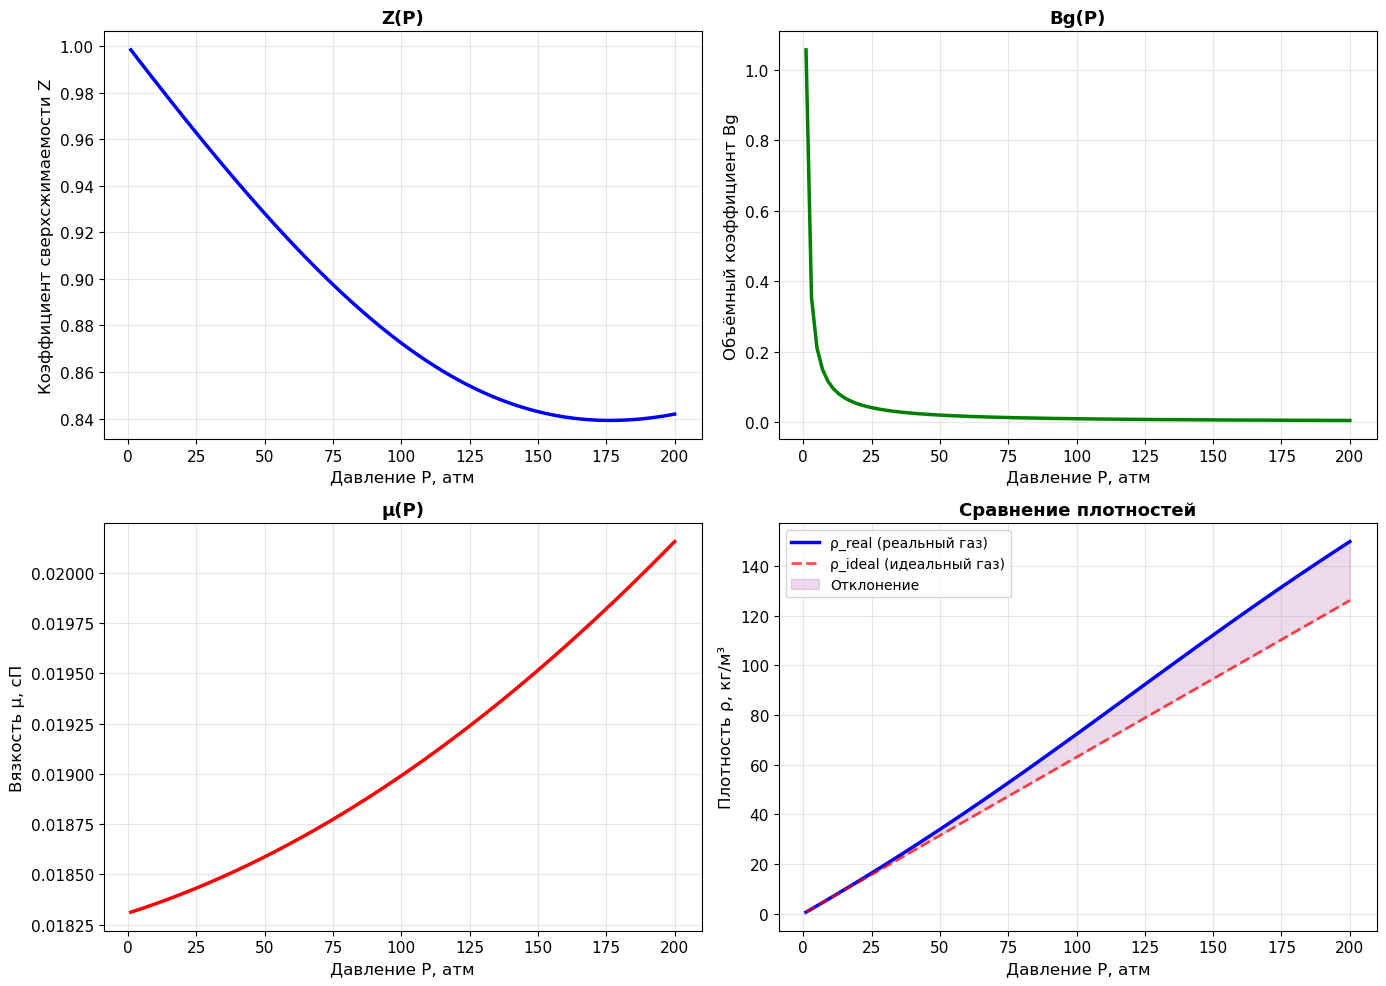

In [176]:
P_range = np.linspace(1, 200, 200)
Z_values = [interp['Z'].predict(p) for p in P_range]
Bg_values = [interp['Bg'].predict(p) for p in P_range]
mu_values = [interp['visc'].predict(p) for p in P_range]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(P_range, Z_values, 'b-', linewidth=2.5)
axes[0, 0].set_xlabel('Давление P, атм', fontsize=12)
axes[0, 0].set_ylabel('Коэффициент сверхсжимаемости Z', fontsize=12)
axes[0, 0].set_title('Z(P)', fontsize=13, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(P_range, Bg_values, 'g-', linewidth=2.5)
axes[0, 1].set_xlabel('Давление P, атм', fontsize=12)
axes[0, 1].set_ylabel('Объёмный коэффициент Bg', fontsize=12)
axes[0, 1].set_title('Bg(P)', fontsize=13, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(P_range, mu_values, 'r-', linewidth=2.5)
axes[1, 0].set_xlabel('Давление P, атм', fontsize=12)
axes[1, 0].set_ylabel('Вязкость μ, сП', fontsize=12)
axes[1, 0].set_title('μ(P)', fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

R_gas = 8.314
M_gas = 0.01604
rho_ideal = [(p * 101325 * M_gas) / (R_gas * T_FIXED) for p in P_range]
rho_real = [rho_ideal[i] / Z_values[i] for i in range(len(P_range))]

axes[1, 1].plot(P_range, rho_real, 'b-', linewidth=2.5, label='ρ_real (реальный газ)')
axes[1, 1].plot(P_range, rho_ideal, 'r--', linewidth=2, alpha=0.7, label='ρ_ideal (идеальный газ)')
axes[1, 1].fill_between(P_range, rho_real, rho_ideal, alpha=0.15, color='purple', label='Отклонение')
axes[1, 1].set_xlabel('Давление P, атм', fontsize=12)
axes[1, 1].set_ylabel('Плотность ρ, кг/м³', fontsize=12)
axes[1, 1].set_title('Сравнение плотностей', fontsize=13, fontweight='bold')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. МОДЕЛЬ ПЛАСТА — КРИВАЯ IPR

Коэффициент продуктивности при P_res = 100.0 атм:
μ(100.0 атм) = 0.018991 сП
C = 65.8964 ст.м³/(сут·атм)


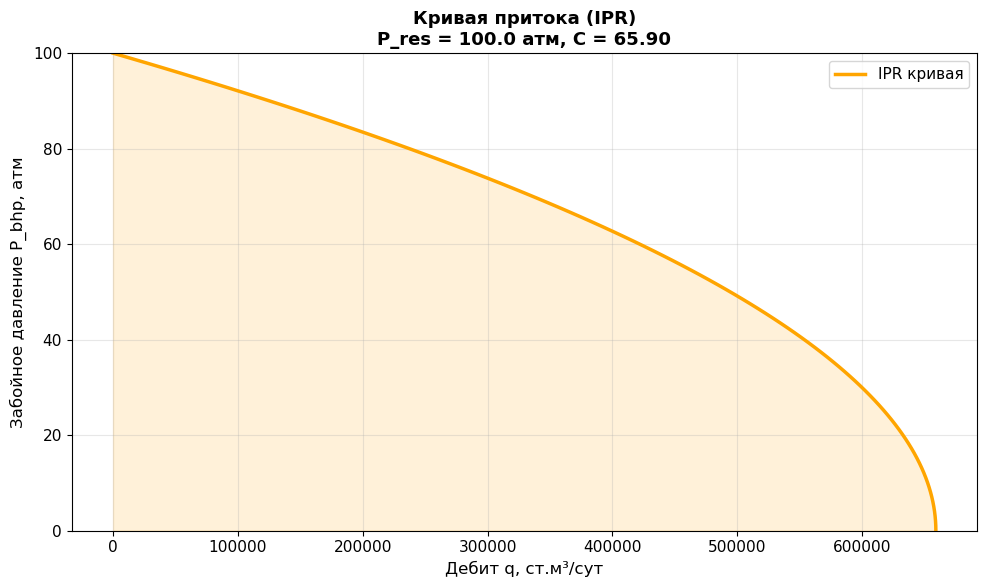

In [177]:
res = Reservoir(k=50.0, h=25.0, re=500.0, rw=0.1, P_res=100.0)

mu_cP = interp['visc'].predict(res.P_res)
C_prod = res.get_productivity_index(mu_cP)

print(f"Коэффициент продуктивности при P_res = {res.P_res} атм:")
print(f"μ({res.P_res} атм) = {mu_cP:.6f} сП")
print(f"C = {C_prod:.4f} ст.м³/(сут·атм)")

P_bhp_range = np.linspace(100, 0, 100)
q_ipr = [res.get_ipr_square(p, C_prod) for p in P_bhp_range]

plt.figure(figsize=(10, 6))
plt.plot(q_ipr, P_bhp_range, color='orange', linewidth=2.5, label='IPR кривая')
plt.fill_between(q_ipr, P_bhp_range, alpha=0.15, color='orange')

plt.xlabel('Дебит q, ст.м³/сут', fontsize=12)
plt.ylabel('Забойное давление P_bhp, атм', fontsize=12)
plt.title(f'Кривая притока (IPR)\nP_res = {res.P_res} атм, C = {C_prod:.2f}', 
          fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.ylim(0, 100)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 3. РАСЧЕТ СИСТЕМЫ, VLP И λ(Re)

Рассчитанное рабочее P_man = 25.8059 атм
Суммарный дебит Q = 1814089.47 ст.м³/сут


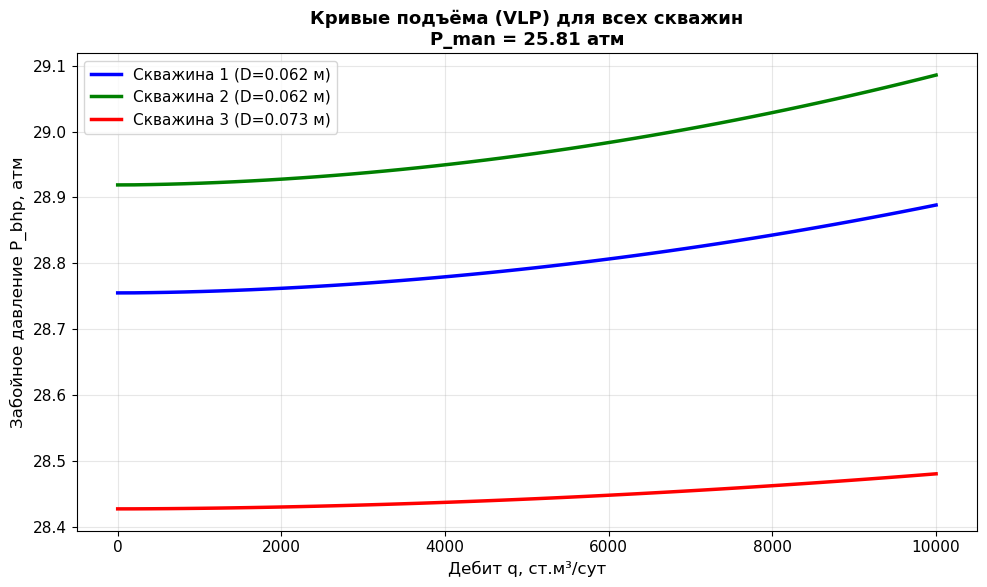

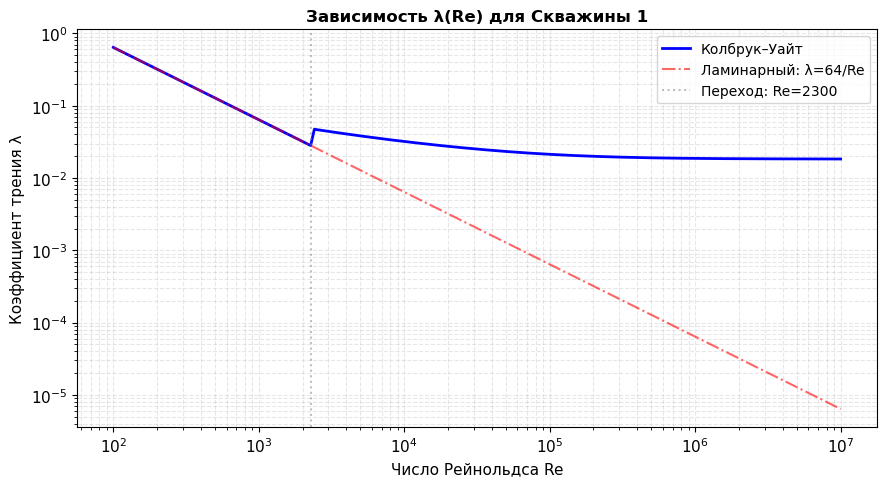

In [178]:
wells_data = {
    'L': [2000, 2500, 1800],
    'D': [0.062, 0.062, 0.073],
    'delta': [0.000046, 0.000046, 0.000046],
    'H': [1800, 1900, 1600],
}

shlyf_L = 5000
shlyf_D = 0.200
shlyf_delta = 0.000046
P_line = 5.0
P_res = 100.0

pipes = []
for i in range(3):
    pipe = Pipe(L=wells_data['L'][i], D=wells_data['D'][i], roughness=wells_data['delta'][i], H=wells_data['H'][i])
    pipes.append(pipe)

shlyf = Pipe(L=shlyf_L, D=shlyf_D, roughness=shlyf_delta, H=0.0)

P_man = P_line + 10.0

for _ in range(50):
    q_total = 0.0
    for pipe in pipes:
        dP_est = pipe.calculate_dP(P_man, 1000, interp)
        P_bhp = P_man + dP_est
        q_well = res.get_ipr_square(P_bhp, C_prod)
        q_total += q_well
    
    dP_shlyf = shlyf.calculate_dP(P_man, q_total, interp)
    P_man_new = P_line + dP_shlyf
    
    if abs(P_man_new - P_man) < 0.01:
        P_man = P_man_new
        break
    P_man = 0.5 * P_man + 0.5 * P_man_new

print(f"Рассчитанное рабочее P_man = {P_man:.4f} атм")
print(f"Суммарный дебит Q = {q_total:.2f} ст.м³/сут")

plt.figure(figsize=(10, 6))
colors = ['blue', 'green', 'red']
for i in range(3):
    q_range = np.linspace(0, 10000, 50)
    qs, pbhps = pipes[i].get_vlp(P_man, q_range, interp)
    plt.plot(qs, pbhps, color=colors[i], linewidth=2.5, label=f'Скважина {i+1} (D={wells_data["D"][i]} м)')

plt.xlabel('Дебит q, ст.м³/сут', fontsize=12)
plt.ylabel('Забойное давление P_bhp, атм', fontsize=12)
plt.title(f'Кривые подъёма (VLP) для всех скважин\nP_man = {P_man:.2f} атм', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

D_test = wells_data['D'][0]
delta_test = wells_data['delta'][0]
rel_rough = delta_test / D_test

Re_range = np.logspace(2, 7, 200)
lambda_vals = [pipes[0]._calc_lambda(Re, rel_rough) for Re in Re_range]

plt.figure(figsize=(9, 5))
plt.loglog(Re_range, lambda_vals, 'b-', linewidth=2, label='Колбрук–Уайт')
plt.loglog(Re_range, [64/Re for Re in Re_range], 'r-.', alpha=0.6, label='Ламинарный: λ=64/Re')
plt.axvline(x=2300, color='gray', linestyle=':', alpha=0.5, label='Переход: Re=2300')

plt.xlabel('Число Рейнольдса Re', fontsize=11)
plt.ylabel('Коэффициент трения λ', fontsize=11)
plt.title(f'Зависимость λ(Re) для Скважины 1', fontsize=12, fontweight='bold')
plt.grid(alpha=0.3, which='both', linestyle='--')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()